In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [32]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\hp\Downloads\archive (1)",
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

train_ds, val_ds = dataset

Found 10028 files belonging to 2 classes.
Using 8023 files for training.
Using 2005 files for validation.


In [33]:
class_names = train_ds.class_names

print(class_names)

['cats', 'dogs']


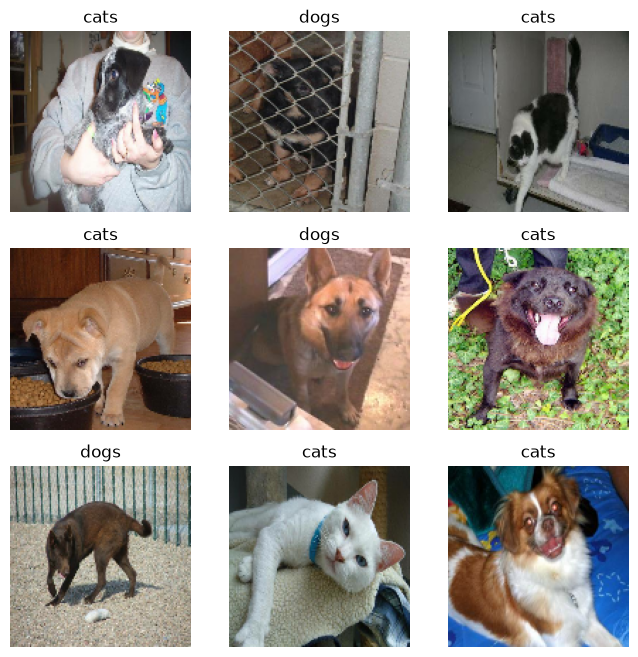

In [34]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.show()

In [35]:
model = Sequential([
    
    tf.keras.layers.Rescaling(
        1./255,
        input_shape=(128,128,3)
    ),

    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [36]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 245ms/step - accuracy: 0.7971 - loss: 0.5043 - val_accuracy: 0.8030 - val_loss: 0.5019
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 250ms/step - accuracy: 0.7971 - loss: 0.4995 - val_accuracy: 0.8030 - val_loss: 0.5056
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 263ms/step - accuracy: 0.7977 - loss: 0.4933 - val_accuracy: 0.8030 - val_loss: 0.5062
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 282ms/step - accuracy: 0.7993 - loss: 0.4762 - val_accuracy: 0.8030 - val_loss: 0.5047
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 293ms/step - accuracy: 0.8064 - loss: 0.4565 - val_accuracy: 0.8025 - val_loss: 0.5187
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 269ms/step - accuracy: 0.8245 - loss: 0.4157 - val_accuracy: 0.8000 - val_loss: 0.5581
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 272ms/step - accuracy: 0.8469 - loss: 0.3652 - val_accuracy: 0.7900 - val_loss: 0.5785
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.8802 - loss: 0

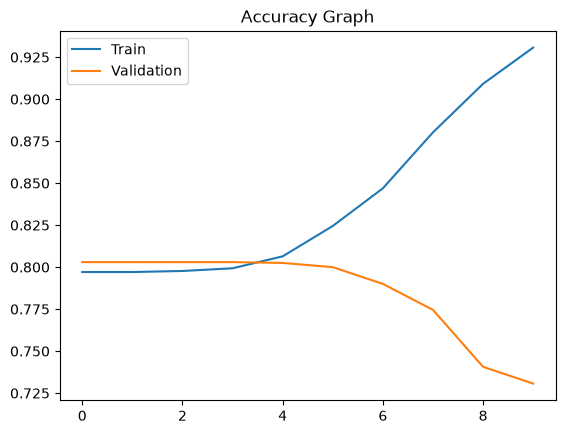

In [40]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.title(
    "Accuracy Graph"
)

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [47]:
img = tf.keras.utils.load_img(
    r"C:\Users\hp\Downloads\archive (1)\dogs\dogs\dog.4941.jpg",
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    0
)

prediction = model.predict(
    img_array
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


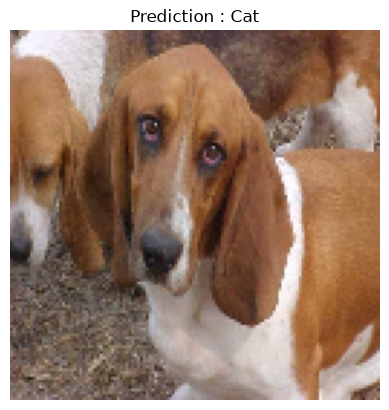

In [48]:
plt.imshow(img)

if prediction[0][0] > 0.5:
    plt.title("Prediction : Dog")
else:
    plt.title("Prediction : Cat")

plt.axis("off")

plt.show()